<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Reconocimiento_de_Placas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fast-alpr[onnx-gpu]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.2/202.2 MB 6.0 MB/s eta 0:00:00


In [ ]:
import cv2
from google.colab.patches import cv2_imshow

In [ ]:
from fast_alpr import ALPR

In [ ]:
# You can also initialize the ALPR with custom plate detection and OCR models.
alpr = ALPR(
    detector_model="yolo-v9-t-384-license-plate-end2end",
    ocr_model="cct-xs-v2-global-model",
)

INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider'] provider(s)


*************** EP Error ***************
EP Error /onnxruntime_src/onnxruntime/python/onnxruntime_pybind_state.cc:573 void onnxruntime::python::RegisterTensorRTPluginsAsCustomOps(PySessionOptions&, const onnxruntime::ProviderOptions&) Please install TensorRT libraries as mentioned in the GPU requirements page, make sure they're in the PATH or LD_LIBRARY_PATH, and that your GPU is supported.
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.
****************************************
*************** EP Error ***************
EP Error /onnxruntime_src/onnxruntime/python/onnxruntime_pybind_state.cc:573 void onnxruntime::python::RegisterTensorRTPluginsAsCustomOps(PySessionOptions&, const onnxruntime::ProviderOptions&) Please install TensorRT libraries as mentioned in the GPU requirements page, make sure they're in the PATH or LD_LIBRARY_PATH, and that your GPU is supported.


In [ ]:
# The "assets/test_image.png" can be found in repo root dir
# You can also pass a NumPy array containing cropped plate image
path='carro4.jpg'
alpr_results = alpr.predict(path)
print(alpr_results)

[ALPRResult(detection=DetectionResult(label='License Plate', confidence=0.9134999513626099, bounding_box=BoundingBox(x1=856, y1=656, x2=1430, y2=952)), ocr=OcrResult(text='6GQW015', confidence=[0.9999498128890991, 0.9999487400054932, 0.9999395608901978, 0.9999839067459106, 0.9833074808120728, 0.9999538660049438, 0.9999608993530273, 0.9999911785125732, 0.9999973773956299, 0.9999988079071045], region='United States', region_confidence=0.9999916553497314))]


In [ ]:
for result in alpr_results:
    print("Placa:", result.ocr.text)
    print("Confianza:", result.detection.confidence)
    print("Región:", result.ocr.region)
    print("Confianza región:", result.ocr.region_confidence)

Placa: 6GQW015
Confianza: 0.9134999513626099
Región: United States
Confianza región: 0.9999916553497314


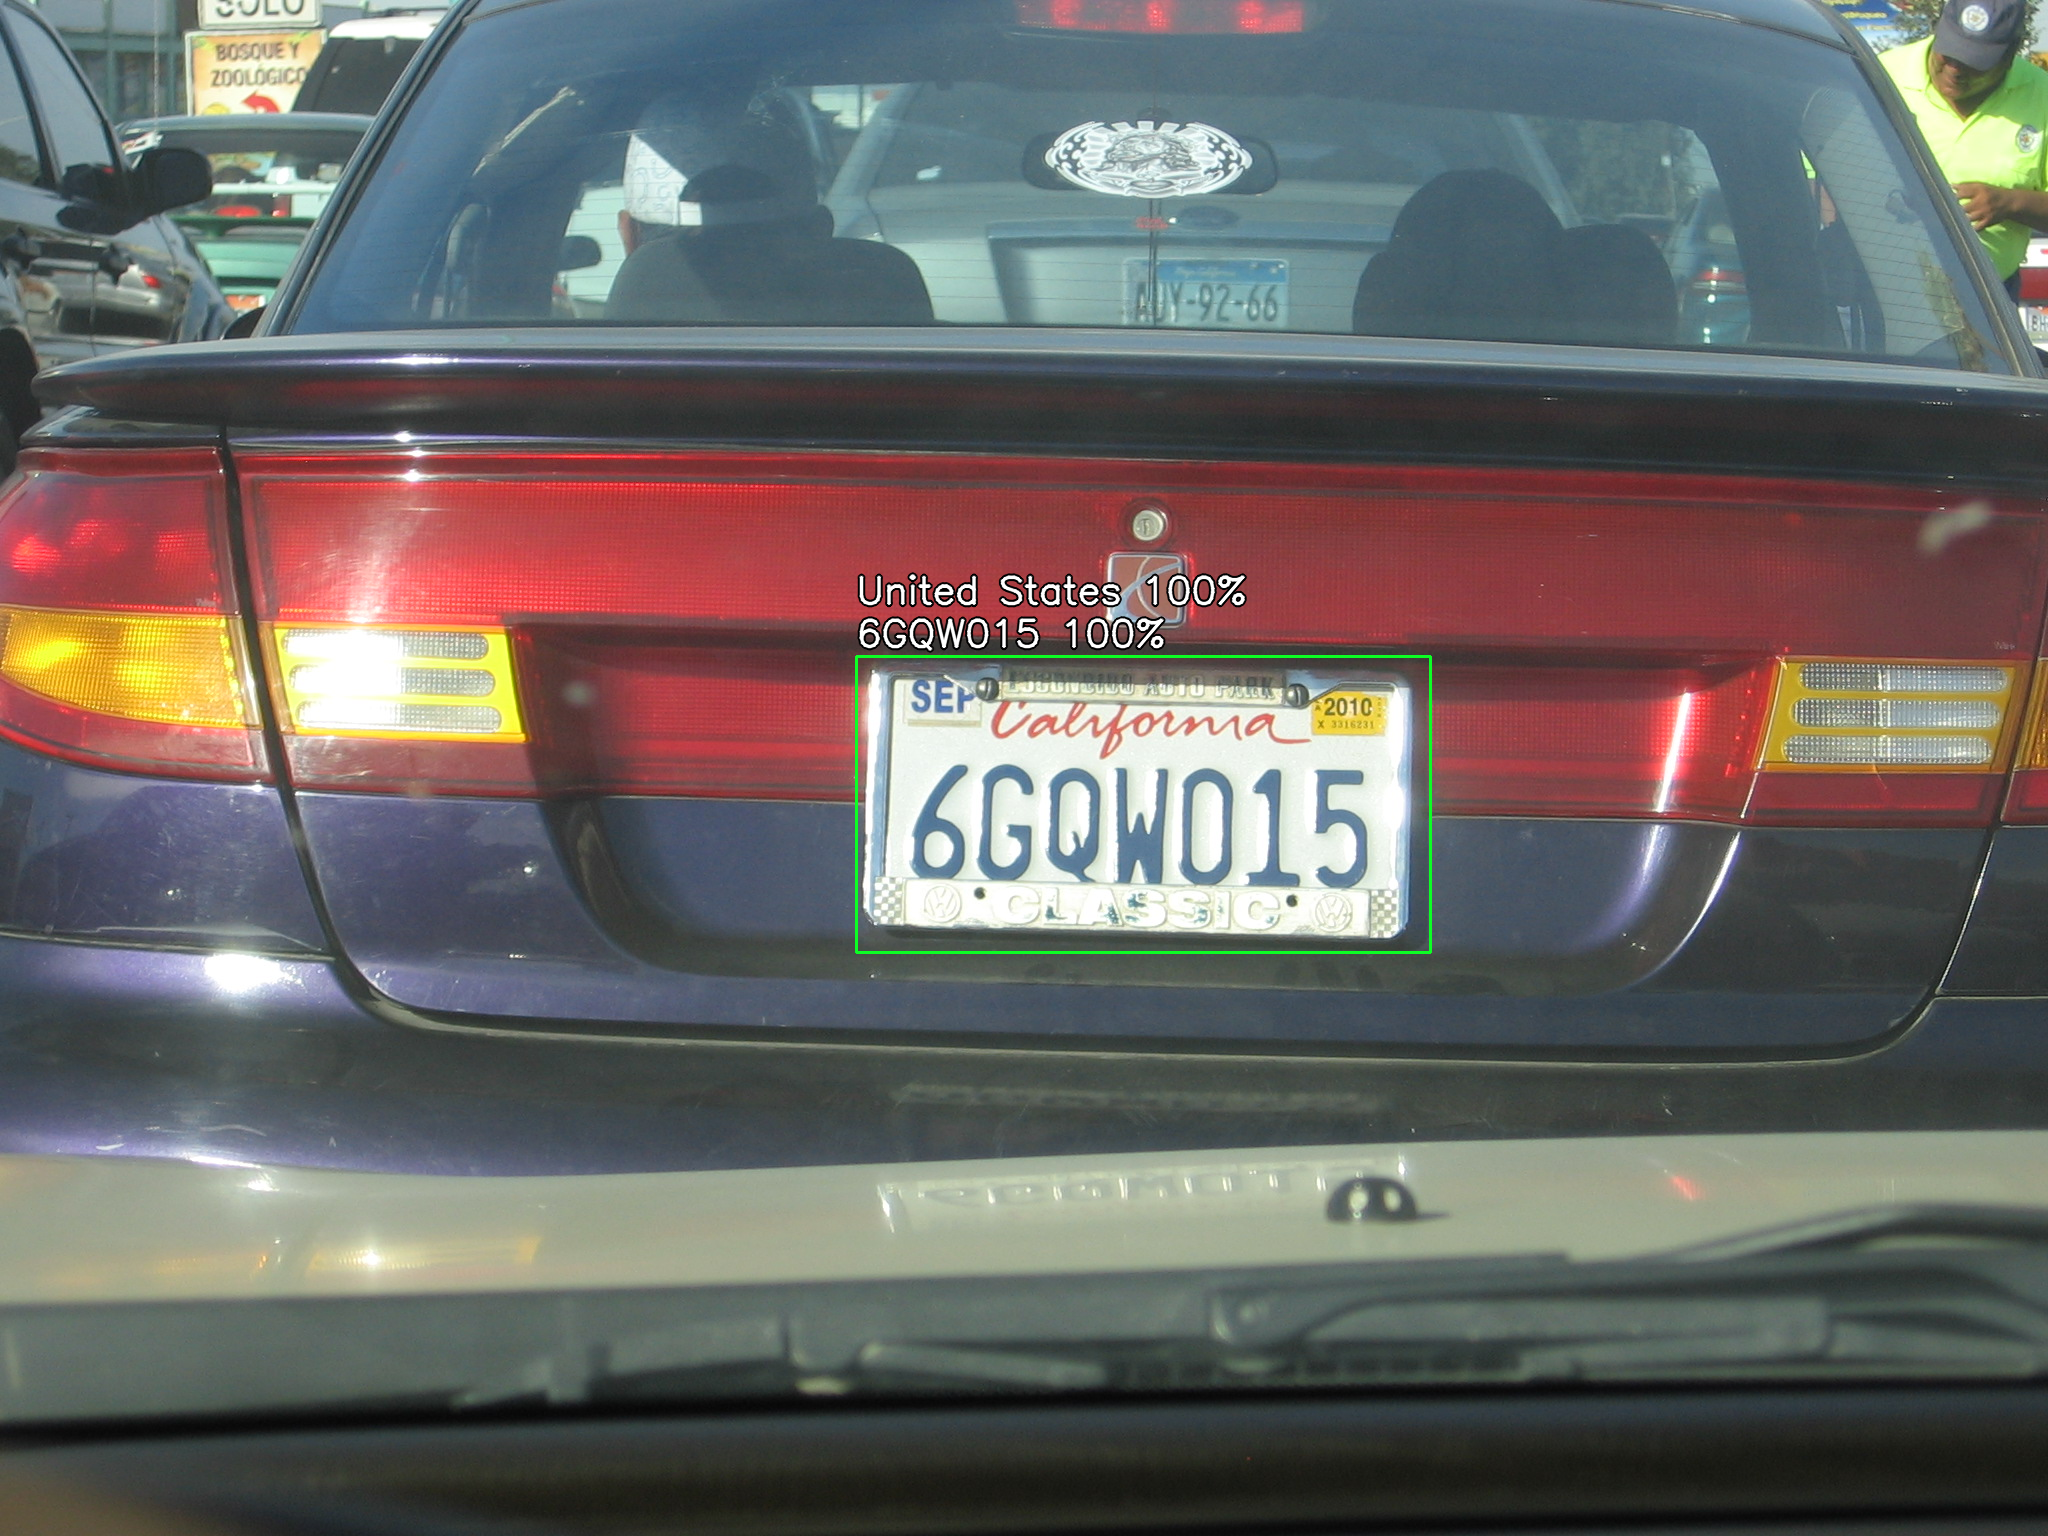

In [ ]:
# Draw predictions on the image and get the ALPR results

frame = cv2.imread(path)
drawn = alpr.draw_predictions(frame)
annotated_frame = drawn.image
results = drawn.results

cv2_imshow(annotated_frame)